# Choi Representation of Quantum Channels

**통합 개요**

이 노트북은 “Choi 표현으로 양자 채널을 어디까지 이해할 수 있는가?”라는 질문에 답하기 위한 전체 프로젝트의 안내서이다. 양자 채널은 양자 상태가 잡음, 측정, 제어, 시간 변화, 실험 장치 등을 거치며 어떻게 변하는지를 나타내는 수학적 대상이다. 하지만 채널을 함수처럼만 생각하면 complete positivity, trace preservation, fidelity, distinguishability 같은 중요한 성질을 한눈에 보기 어렵다. Choi 표현은 이 채널을 하나의 행렬 `C_E`로 바꾸어 주어, 물리적 가능성과 성능 지표를 선형대수와 최적화 문제로 다룰 수 있게 한다.

이 프로젝트는 다섯 Agent가 서로 다른 방향에서 같은 아이디어를 탐구한 결과를 통합한다. Agent-1은 Kraus, Choi, Stinespring, natural representation 사이의 변환과 표준 채널을 정리했다. Agent-2는 process tomography를 통해 실험 또는 시뮬레이션 데이터에서 Choi 행렬을 재구성하고, 그 행렬로 gate 품질과 noise signature를 진단했다. Agent-3은 두 채널을 최적으로 구별하는 문제를 diamond norm SDP로 풀어, Choi 표현이 operational task와 연결됨을 보였다. Agent-4는 단일 시간 채널을 넘어 quantum comb와 process tensor를 사용해 memory가 있는 multi-time dynamics를 설명했다. Agent-5는 interactive widget을 통해 Choi eigenvalue, CP/TP 조건, Bloch sphere deformation을 직접 관찰할 수 있게 했다.

이 문서는 개별 노트북의 모든 증명과 실험을 반복하지 않는다. 대신 각 파트가 무엇을 했고, 왜 필요한지, 그리고 서로 어떻게 이어지는지를 초심자가 따라올 수 있도록 하나의 흐름으로 설명한다. 세부 구현과 추가 실험은 각 폴더의 `main.ipynb`와 `README.md`에 있다.

## Introduction

Choi 표현이 중요한 이유는 양자 채널을 “상태를 상태로 보내는 함수”에서 “검사 가능한 행렬”로 바꾸어 주기 때문이다. 양자 상태는 density matrix로 표현되고, 양자 채널은 이 density matrix를 다른 density matrix로 보내는 선형 map이다. 예를 들어 실제 양자 하드웨어에서 gate를 적용하면 이상적인 unitary만 작용하는 것이 아니라 decoherence, relaxation, calibration error 같은 잡음도 함께 작용한다. 이런 전체 작용을 하나의 quantum channel로 볼 수 있다.

그런데 모든 선형 map이 물리적으로 가능한 채널은 아니다. 물리적인 채널이라면 적어도 두 조건을 만족해야 한다. 첫째, 완전양성성(complete positivity, CP)이다. 이는 채널이 단독 system뿐 아니라 외부 ancilla와 얽힌 더 큰 system 위에서도 음수가 아닌 물리적 상태를 유지해야 함을 뜻한다. 둘째, trace preservation(TP)이다. 이는 확률의 총합이 보존되어야 하므로 density matrix의 trace가 유지되어야 함을 뜻한다.

Choi 행렬을 사용하면 이 두 조건이 매우 구체적인 행렬 조건으로 바뀐다. 이 프로젝트의 공통 convention은

```text
C_E = sum_ij |i><j|_A tensor E(|i><j|)_B
```

이다. 여기서 `A`는 input system, `B`는 output system이다. 이 convention에서는 `C_E >= 0`이면 채널이 CP이고, `Tr_B(C_E) = I_A`이면 채널이 TP이다. 즉 추상적인 물리 조건이 eigenvalue 계산과 partial trace 계산으로 바뀐다.

이 노트북은 다섯 개의 세부 노트북을 하나의 guided tour로 묶는다. 먼저 Agent-1의 이론 파트에서 Choi 행렬이 무엇인지 보고, Agent-2의 tomography 파트에서 그 행렬을 데이터로부터 어떻게 얻는지 살핀다. 이어 Agent-3의 SDP 파트에서 Choi 행렬이 channel discrimination이라는 의사결정 문제의 입력이 되는 과정을 본다. Agent-4에서는 단일 채널의 Choi 행렬이 multi-time process의 quantum comb로 확장되는 모습을 보고, Agent-5에서는 위 내용을 시각적으로 조작하며 직관을 만든다.

In [1]:
# 공통 설정
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import choi_common
from choi_common.channels import (
    amplitude_damping_channel_choi,
    depolarizing_channel_choi,
)
from choi_common.metrics import solve_diamond_norm_sdp
from choi_common.validation import choi_rank, is_cp, is_tp
from choi_common.visualization import plot_choi_heatmap, plot_eigenspectrum

np.random.seed(42)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": False,
    "font.size": 10,
})

PROJECT_ROOT = Path.cwd()
PALETTE = {
    "blue": "#2563eb",
    "orange": "#f97316",
    "green": "#16a34a",
    "red": "#dc2626",
    "gray": "#475569",
}

print("choi_common imported from:", Path(choi_common.__file__).resolve())

choi_common imported from: C:\Users\jaehy\qiqc_project\choi_common\__init__.py


<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 전체 notebook에서 공통으로 사용할 library와 plotting style을 준비한다. 출력된 `choi_common imported from: ...` 경로는 현재 notebook이 root에 만들어진 shared library `choi_common`을 제대로 import하고 있음을 확인해 준다. 이후 모든 예제는 이 공통 library의 Choi convention과 helper function을 사용한다.

## Foundations: Channel Representations

Agent-1의 핵심 목표는 “같은 quantum channel을 여러 표현으로 일관되게 다룰 수 있는가?”를 확인하는 것이었다. 채널은 하나의 수학적 대상이지만, 계산 목적에 따라 여러 방식으로 표현된다. Kraus representation은 채널을 여러 operator `K_k`의 합으로 표현하며, 잡음 과정이 어떤 branch들로 구성되는지 이해하기 좋다. Choi representation은 채널 전체를 하나의 행렬로 압축해 CP/TP 검사와 rank 분석에 유리하다. Stinespring representation은 channel을 더 큰 Hilbert space에서 unitary-like isometry로 보는 관점이고, natural 또는 Liouville representation은 density matrix를 vectorize했을 때 channel을 ordinary matrix multiplication으로 적용하는 관점이다.

초심자에게 가장 중요한 연결은 다음과 같다. Kraus operator가 주어지면 `kraus_to_choi`로 Choi 행렬을 만들 수 있고, Choi 행렬의 eigen-decomposition을 이용하면 다시 Kraus operator들을 복원할 수 있다. 이때 0이 아닌 Choi eigenvalue의 개수, 즉 Choi rank는 필요한 Kraus operator의 최소 개수와 연결된다. 따라서 Choi 행렬은 단순히 다른 표기법이 아니라, channel의 구조적 복잡도를 알려 주는 object이다.

이 프로젝트에서는 모든 폴더가 같은 unnormalized Choi convention을 사용하도록 맞추었다. 이 통일이 중요하다. Choi 행렬은 normalize 방식이나 tensor factor 순서가 다르면 같은 channel도 다른 matrix layout으로 나타난다. convention이 다르면 partial trace 방향, fidelity 계산, SDP 입력이 모두 어긋날 수 있다. 그래서 통합 작업에서는 `input A first, output B second`와 `Tr_B(C_E) = I_A`를 공통 기준으로 삼았다.

아래 예시는 qubit depolarizing channel의 Choi 행렬을 만든다. Depolarizing channel은 원래 상태를 일정 확률로 섞어 버리는 대표적인 noise model이다. heatmap은 Choi 행렬의 real/imaginary/magnitude 구조를 보여 주고, eigenspectrum은 CP 여부와 Choi rank를 직관적으로 보여 준다.

shape: (4, 4)
CP: True
TP: True
Choi rank: 4


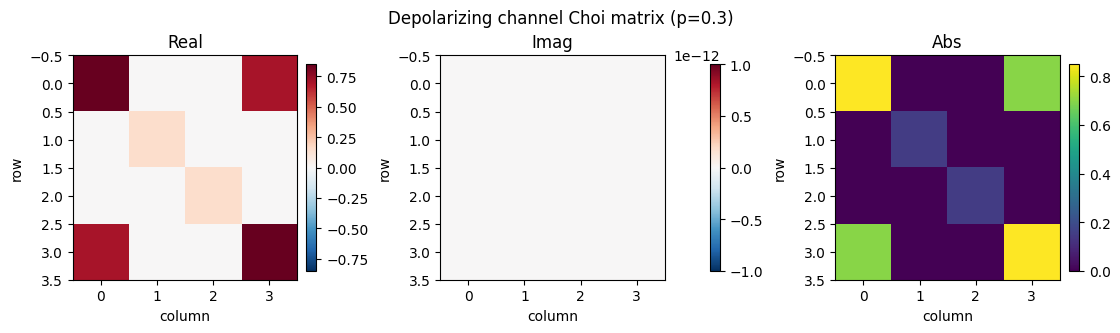

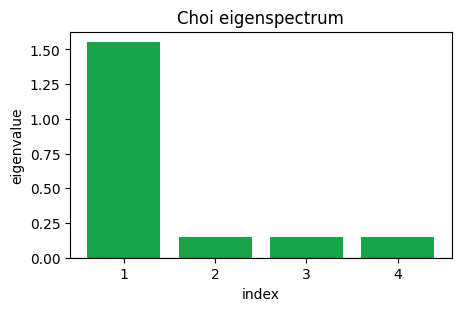

In [2]:
# 예시: qubit depolarizing channel의 Choi 행렬
p = 0.30
choi_dep = depolarizing_channel_choi(p, d=2, convention="replacement")

print("shape:", choi_dep.shape)
print("CP:", is_cp(choi_dep))
print("TP:", is_tp(choi_dep, d_in=2, d_out=2))
print("Choi rank:", choi_rank(choi_dep))

fig = plot_choi_heatmap(
    choi_dep,
    title=f"Depolarizing channel Choi matrix (p={p})",
    include_abs=True,
)
plt.show()

fig, ax = plt.subplots(figsize=(4.5, 3.0), constrained_layout=True)
plot_eigenspectrum(choi_dep, ax=ax)
plt.show()

<!-- 실행 결과 해설 -->
### 실행 결과 해설

`shape: (4, 4)`는 qubit channel의 Choi matrix가 input dimension 2와 output dimension 2를 합쳐 `d_in*d_out = 4` 크기의 square matrix가 됨을 의미한다. `CP: True`는 Choi matrix가 positive semidefinite라서 complete positivity 조건을 만족한다는 뜻이고, `TP: True`는 `Tr_B(C_E)=I_A`가 수치적으로 성립한다는 뜻이다. `Choi rank: 4`는 이 depolarizing channel을 Kraus representation으로 쓰려면 일반적으로 네 개의 Kraus branch가 필요함을 보여 준다.

첫 번째 그림의 heatmap은 Choi matrix의 real, imaginary, magnitude 구조를 보여 준다. 두 번째 eigenspectrum plot에서는 eigenvalue가 모두 음수가 아님을 확인할 수 있다. 따라서 이 예시는 physical channel의 기본 조건을 시각적으로 확인하는 역할을 한다.

> 전체 이론 전개, representation 변환, 표준 채널 생성자, CP/TP 검사, round-trip test는 [01_theory/main.ipynb](01_theory/main.ipynb)에 정리되어 있다. 특히 이 master notebook에서 사용하는 `choi_common` 함수들의 원형은 Agent-1의 구현과 여러 producer 폴더의 중복 구현을 바탕으로 통합되었다.

## Process Tomography: Hardware-Ready Reconstruction

Agent-2의 역할은 이론적으로 정의한 Choi 행렬을 실제 데이터 분석 흐름으로 가져오는 것이었다. Process tomography는 알려진 입력 상태들을 준비하고, channel을 통과한 뒤의 출력 상태를 측정하여 channel 자체를 재구성하는 절차이다. 상태 tomography가 “상태가 무엇인가?”를 묻는다면, process tomography는 “장치나 gate가 상태를 어떻게 바꾸는가?”를 묻는다.

이 파트에서 Choi 행렬은 진단 도구가 된다. 재구성된 Choi 행렬의 eigenvalue를 보면 reconstructed channel이 CP 조건을 만족하는지 확인할 수 있다. output subsystem에 대한 partial trace를 계산하면 TP 조건이 얼마나 잘 맞는지 볼 수 있다. ideal Choi matrix와 reconstructed Choi matrix를 비교하면 process fidelity, average gate fidelity, diamond-distance diagnostic 같은 지표를 얻을 수 있다.

Agent-2의 notebook은 IBM Quantum hardware submission을 염두에 두고 설계되었지만, 기본 실행은 offline-reproducible하다. 즉 IBM 계정이나 queue time 없이도 deterministic simulated data를 사용해 전체 분석 흐름을 재현할 수 있다. 저장된 sample에서는 `X`, `H`, `CNOT` gate에 대해 ideal channel 뒤에 amplitude damping 또는 depolarizing noise를 붙인 stand-in channel을 만들고, 이를 tomography 결과처럼 분석한다.

아래 코드는 저장된 `raw_results.json`에서 `X` gate 결과를 읽는다. 왼쪽 그림은 ideal `X` gate의 Choi 행렬이고, 오른쪽은 noise가 포함된 reconstructed Choi 행렬이다. 두 heatmap의 차이는 단순한 그림 차이가 아니라, fidelity 감소와 diamond distance 증가로 이어지는 물리적 차이이다.

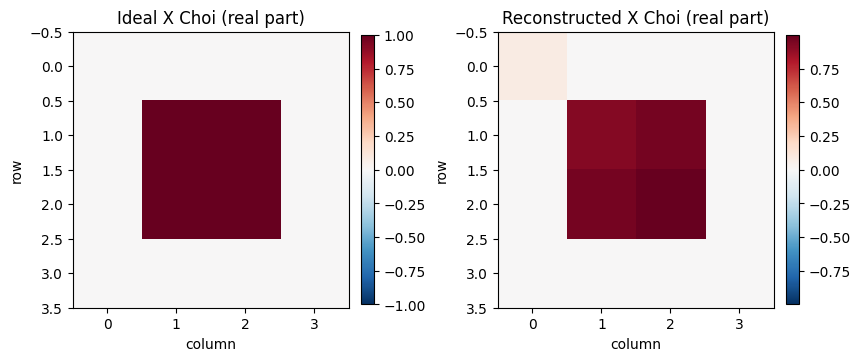

mode: offline_simulated
noise model: amplitude_damping_after_unitary(gamma=0.08)
process fidelity: 0.959583
average gate fidelity: 0.973055
half diamond distance: 0.08
CP / TP: True True
dominant noise: amplitude-damping-like relaxation


In [3]:
def _matrix_from_json_payload(payload: dict) -> np.ndarray:
    def rows_to_array(rows):
        parsed = []
        for row in rows:
            if isinstance(row, str):
                parsed.append([float(x) for x in row.split()])
            else:
                parsed.append([float(x) for x in row])
        return np.array(parsed, dtype=float)

    return rows_to_array(payload["real"]) + 1j * rows_to_array(payload["imag"])

raw_path = PROJECT_ROOT / "02_ibm_experiment" / "data" / "raw_results.json"
raw = json.loads(raw_path.read_text(encoding="utf-8"))

x_gate = raw["gates"]["X"]
ideal_x = _matrix_from_json_payload(x_gate["ideal_choi"])
reconstructed_x = _matrix_from_json_payload(x_gate["reconstructed_choi"])
diagnosis = x_gate["diagnosis"]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [ideal_x.real, reconstructed_x.real],
    ["Ideal X Choi (real part)", "Reconstructed X Choi (real part)"],
):
    vmax = max(float(np.max(np.abs(matrix))), 1e-12)
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

print("mode:", raw["mode"])
print("noise model:", x_gate["noise_model"])
print("process fidelity:", round(diagnosis["process_fidelity"], 6))
print("average gate fidelity:", round(diagnosis["average_gate_fidelity"], 6))
print("half diamond distance:", round(diagnosis["diamond_distance"], 6))
print("CP / TP:", diagnosis["is_cp"], diagnosis["is_tp"])
print("dominant noise:", diagnosis["dominant_noise"])

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 실제 IBM hardware를 호출하지 않고 저장된 offline simulated tomography 결과를 읽는다. 그림은 ideal `X` gate의 Choi matrix와 reconstructed noisy `X` process의 Choi matrix를 비교한다. 두 행렬이 완전히 같지 않기 때문에 fidelity가 1보다 작고 diamond distance가 0보다 크다.

출력에서 `process fidelity: 0.959583`과 `average gate fidelity: 0.973055`는 reconstructed process가 ideal `X` gate에 꽤 가깝지만 완벽하지는 않다는 뜻이다. `half diamond distance: 0.08`은 이 차이가 operational하게 감지될 수 있는 정도를 SDP 기반 metric으로 요약한 값이다. `dominant noise: amplitude-damping-like relaxation`은 Bloch sphere translation과 Kraus weight 패턴을 바탕으로 noise가 relaxation 성격을 가진다고 진단한 결과이다.

> Agent-2의 전체 workflow, linear inversion, CVXPY 기반 CPTP projection, MLE-style projection, IBM Quantum submission/retrieval pattern은 [02_ibm_experiment/main.ipynb](02_ibm_experiment/main.ipynb)에 있다. 이 master notebook은 hardware access 없이 저장된 결과만 사용하므로 재실행이 빠르고 안정적이다.

## Channel Discrimination via SDP

Agent-3은 Choi 표현을 “채널을 얼마나 잘 구별할 수 있는가?”라는 operational question에 연결했다. 두 quantum channel `E_0`, `E_1`이 있고 둘 중 하나가 같은 확률로 주어진다고 하자. 우리는 어떤 입력 상태를 넣고 어떤 measurement를 해야 어느 channel이 사용되었는지 가장 잘 맞힐 수 있을까? 이 문제가 quantum channel discrimination이다.

Equal prior인 경우 최적 성공확률은 다음 식으로 표현된다.

```text
p_success = 1/2 + 1/4 ||E_0 - E_1||_diamond
```

여기서 diamond norm은 두 channel의 operational distance이다. 단순히 Choi 행렬의 Frobenius norm이나 trace norm을 계산하는 것과 다르다. Diamond norm은 channel이 ancilla와 함께 사용될 가능성까지 고려한다. 그래서 어떤 경우에는 product input만 사용할 때보다 entangled input을 사용할 때 channel을 더 잘 구별할 수 있다.

Watrous의 SDP formulation은 channel difference `Phi = E_0 - E_1`의 Choi matrix `C_Phi`를 입력으로 사용한다. 즉 Agent-1에서 정의한 Choi convention이 Agent-3의 최적화 문제로 그대로 이어진다. Agent-2의 reconstructed Choi matrix가 있다면, ideal channel과 reconstructed channel의 차이를 같은 방식으로 discrimination 또는 error-detection 관점에서 분석할 수 있다.

아래 예시는 작은 qubit 문제를 푼다. `depolarizing_channel_choi(0.25)`와 `amplitude_damping_channel_choi(0.25)`를 만들고, 두 Choi 행렬의 차이에 대해 diamond norm SDP를 푼다. 결과로 나오는 optimal success probability는 “이 두 noise model을 한 번의 channel use로 구별할 때 이론적으로 가능한 최고 성공률”로 해석할 수 있다.

solver: CLARABEL
status: optimal
diamond norm: 0.295549
optimal equal-prior success probability: 0.573887
optimal input state candidate rho:
[[ 0.500003 -0.      ]
 [-0.        0.499997]]


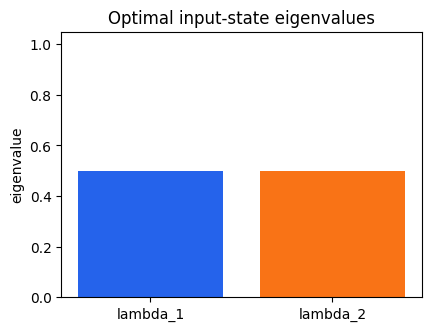

In [4]:
choi_0 = depolarizing_channel_choi(0.25, d=2, convention="replacement")
choi_1 = amplitude_damping_channel_choi(0.25)
choi_diff = choi_0 - choi_1

try:
    result = solve_diamond_norm_sdp(choi_diff, d_in=2, d_out=2, max_iters=20_000)
    p_success = 0.5 + 0.25 * result.value

    print("solver:", result.solver)
    print("status:", result.status)
    print("diamond norm:", round(result.value, 6))
    print("optimal equal-prior success probability:", round(p_success, 6))
    print("optimal input state candidate rho:")
    print(np.round(result.rho.real, 6))

    fig, ax = plt.subplots(figsize=(4.2, 3.2), constrained_layout=True)
    eigvals = np.linalg.eigvalsh(result.rho)
    ax.bar(["lambda_1", "lambda_2"], np.real(eigvals), color=[PALETTE["blue"], PALETTE["orange"]])
    ax.set_ylim(0, 1.05)
    ax.set_title("Optimal input-state eigenvalues")
    ax.set_ylabel("eigenvalue")
    plt.show()
except Exception as exc:
    print("SDP example was skipped because CVXPY/solver execution failed.")
    print(type(exc).__name__ + ":", exc)

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 depolarizing channel과 amplitude damping channel을 구별하는 작은 SDP를 푼다. `solver: CLARABEL`과 `status: optimal`은 CVXPY가 CLARABEL solver로 최적해를 찾았음을 뜻한다. `diamond norm`은 두 channel difference의 operational norm이고, `optimal equal-prior success probability`는 두 channel 중 어느 것이 주어졌는지 한 번의 사용으로 맞힐 수 있는 최고 성공확률이다.

성공확률이 약 `0.573887`로 0.5보다 조금 크다는 것은 두 noise channel이 완전히 같지는 않지만, 한 번의 channel use만으로는 매우 쉽게 구별되지는 않는다는 의미이다. 출력된 `rho`가 거의 maximally mixed state에 가까운 것은 이 예제에서 최적 input marginal이 특정 basis state에 강하게 치우치지 않음을 보여 준다.

> Agent-3의 notebook인 [03_sdp_discrimination/main.ipynb](03_sdp_discrimination/main.ipynb)는 Pauli channel과 depolarizing channel의 closed-form 결과 검증, identity vs completely depolarizing channel의 entanglement advantage, multi-shot tensor-power scaling까지 다룬다. 이 master notebook의 예시는 전체 논리의 가장 작은 실행 가능한 조각이다.

## Beyond Single-Step Channels: Quantum Combs

Agent-4는 Choi 표현을 단일 channel에서 multi-time process로 확장했다. 단일 Choi 행렬은 한 번의 channel use, 즉 `input -> output` 관계를 잘 설명한다. 하지만 open quantum system에서는 현재의 dynamics가 과거 interaction의 영향을 받을 수 있다. 예를 들어 system이 environment와 상호작용한 뒤, 같은 environment와 다시 상호작용하면 두 번째 변화는 첫 번째 변화와 독립적이지 않다. 이런 상황을 memory effect 또는 non-Markovian dynamics라고 부른다.

초심자에게 중요한 점은 “각 시간의 channel이 모두 물리적으로 가능하다”는 사실만으로 전체 process가 memoryless라는 결론을 내릴 수 없다는 것이다. 각 시간 slice의 marginal channel은 CPTP일 수 있지만, 시간 사이의 correlation은 별도의 정보이다. Quantum comb 또는 process tensor는 이 multi-time correlation을 포함하는 더 큰 Choi-like operator `T`로 생각할 수 있다.

Agent-4의 convention은 subsystem order를 `A0, B0, A1, B1, ...`로 둔다. 이는 첫 번째 입력/출력, 두 번째 입력/출력, ...을 하나의 큰 tensor structure에 넣는 방식이다. 단일 channel에서 `C_E >= 0`과 partial trace 조건이 중요했던 것처럼, comb에서도 positivity와 causality constraints가 중요하다. 또한 Markovian process라면 전체 comb가 one-step marginal들의 product 형태로 factorize되어야 한다는 직관을 사용할 수 있다.

아래 그림은 두 가지 comb를 비교한다. 왼쪽은 memoryless product comb이고, 오른쪽은 같은 environment를 재사용하는 finite-memory collision comb이다. 두 matrix는 같은 크기를 갖지만, finite-memory comb는 product factorization으로 설명되지 않는 off-structure correlation을 갖는다. `comb_correlation_norm`은 이런 차이를 숫자로 요약하는 교육용 diagnostic이다.

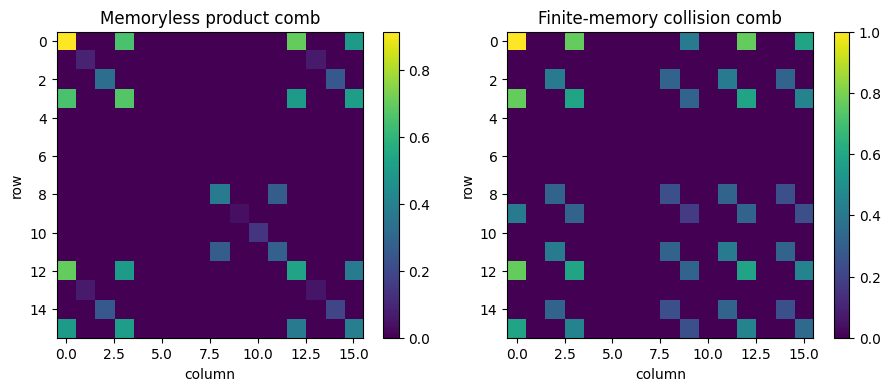

memoryless correlation norm: 0.0
finite-memory correlation norm: 0.50731


In [5]:
COMB_DIR = PROJECT_ROOT / "04_quantum_combs"
if str(COMB_DIR) not in sys.path:
    sys.path.insert(0, str(COMB_DIR))

from non_markovian_dynamics import (  # noqa: E402
    choi_abs_matrix,
    collision_model_comb,
    comb_correlation_norm,
    memoryless_product_comb,
)

memoryless = memoryless_product_comb(theta=0.7, n_steps=2)
with_memory = collision_model_comb(theta=0.7, n_steps=2)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [choi_abs_matrix(memoryless), choi_abs_matrix(with_memory)],
    ["Memoryless product comb", "Finite-memory collision comb"],
):
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

print("memoryless correlation norm:", round(comb_correlation_norm(memoryless), 6))
print("finite-memory correlation norm:", round(comb_correlation_norm(with_memory), 6))

<!-- 실행 결과 해설 -->
### 실행 결과 해설

두 heatmap은 memoryless product comb와 finite-memory collision comb의 magnitude structure를 비교한다. `memoryless correlation norm: 0.0`은 product comb가 one-step marginal들의 곱으로 정확히 설명됨을 뜻한다. 반면 `finite-memory correlation norm: 0.50731`은 같은 environment가 재사용되면서 time slot 사이 correlation이 생겼고, ordinary single-step channel들의 product만으로는 전체 process를 설명할 수 없다는 뜻이다.

> Agent-4의 전체 설명은 [04_quantum_combs/main.ipynb](04_quantum_combs/main.ipynb)에 있다. 그곳에서는 BLP trace-distance revival, RHP-style CP-divisibility witness, deterministic-comb causality check, collision model의 memory effect를 더 자세히 보여 준다.

## Interactive Exploration

Agent-5는 Choi 표현을 눈으로 보고 손으로 조작할 수 있는 widget으로 만들었다. 수식만 보면 CP, TP, Choi rank, Bloch deformation이 서로 다른 개념처럼 보일 수 있다. 하지만 qubit channel에서는 slider를 움직일 때 이 값들이 함께 변하는 모습을 보면 관계가 훨씬 명확해진다.

예를 들어 depolarizing strength `p`를 키우면 Bloch sphere가 더 작아지고, Choi 행렬의 eigenvalue 분포가 바뀐다. Amplitude damping에서는 sphere가 단순히 줄어드는 것이 아니라 한쪽으로 이동한다. General unital map에서는 parameter가 CP tetrahedron 밖으로 나가면 Choi eigenvalue가 음수가 되어 CP indicator가 실패한다. 이런 예시는 `C_E >= 0`이라는 조건이 단순한 형식적 조건이 아니라 실제 channel action의 가능성을 제한하는 물리 조건임을 보여 준다.

Widget은 또한 다른 Agent들의 결과를 읽는 데 필요한 감각을 준다. Agent-2의 tomography table에서 `min_choi_eigenvalue`, `tp_residual`, `kraus_weights`를 볼 때 이 값들이 무엇을 의미하는지 이해하기 쉬워진다. Agent-3에서 diamond distance가 커지는 경우에는 실제 Bloch action이 더 크게 달라진다고 예상할 수 있다. Agent-4의 comb는 더 큰 구조라 직접 widget으로 표현되지는 않지만, “행렬 구조를 보고 물리적 의미를 읽는다”는 태도는 그대로 이어진다.

아래 셀은 `05_interactive_widget`의 dashboard를 불러온다. 정적 실행 결과에서는 widget representation만 보일 수 있지만, Jupyter 환경에서 직접 열면 dropdown과 slider를 조작할 수 있다.

In [6]:
WIDGET_DIR = PROJECT_ROOT / "05_interactive_widget"
if str(WIDGET_DIR) not in sys.path:
    sys.path.insert(0, str(WIDGET_DIR))

try:
    from widget_core import build_widget  # noqa: E402

    display(build_widget())
except Exception as exc:
    display(Markdown(
        "**Widget launch skipped.** "
        "`05_interactive_widget`의 optional widget dependency가 현재 kernel에서 준비되지 않았습니다."
    ))
    print(type(exc).__name__ + ":", exc)

<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 Agent-5의 interactive widget을 notebook 안에 표시한다. Static export에서는 widget object의 representation만 보일 수 있지만, JupyterLab이나 classic Notebook에서 열면 dropdown과 slider를 직접 조작할 수 있다. Widget은 Choi matrix, Bloch deformation, Choi eigenvalue, CP/TP indicator를 한 화면에서 연결해 보여 주므로 앞선 section들의 수식적 조건을 시각적으로 확인하는 데 사용된다.

> Agent-5의 source notebook은 [05_interactive_widget/main.ipynb](05_interactive_widget/main.ipynb)이다. 지원 채널, CP/TP indicator, Kraus display, eigenspectrum, Bloch deformation figure의 세부 구현은 `widget_core.py`에 정리되어 있다.

## Synthesis and Connections

다섯 Agent의 작업은 서로 독립적인 주제처럼 보이지만, 실제로는 하나의 공통 interface를 공유한다. 그 interface가 Choi 행렬이다. Agent-1은 이 interface의 문법을 만든다. 어떤 channel이 Kraus operator로 주어지든, unitary와 noise model로 주어지든, natural representation으로 주어지든, 최종적으로 같은 convention의 `C_E`로 변환할 수 있어야 한다. 이 덕분에 나머지 Agent들은 서로 다른 문제를 풀면서도 같은 CP/TP 조건과 같은 matrix layout을 사용할 수 있다.

Agent-1의 이론은 Agent-2의 실험 분석을 가능하게 한다. Process tomography에서 측정 데이터만 얻는다면 그것은 아직 channel object가 아니다. Linear inversion이나 CPTP projection을 통해 reconstructed Choi matrix를 만들고 나서야, 우리는 그 장치가 어떤 channel처럼 행동했는지 말할 수 있다. 이때 Agent-1에서 정리한 `C_E >= 0`, `Tr_B(C_E) = I_A`, Choi rank, Kraus recovery 같은 도구가 그대로 진단 기준이 된다.

Agent-2의 reconstructed Choi matrix는 Agent-3의 discrimination 문제로 이어진다. 예를 들어 reconstructed `X` gate가 ideal `X` gate와 얼마나 다른지 알고 싶을 때, fidelity는 “얼마나 비슷한가”를 알려 주는 한 가지 지표이다. 반면 diamond distance는 “이 차이를 어떤 입력 상태와 measurement로 operational하게 감지할 수 있는가”에 더 직접적으로 연결된다. 따라서 tomography 결과는 단순한 품질표를 넘어, 실제로 channel을 구별하거나 error를 탐지하는 최적화 문제의 입력이 될 수 있다.

Agent-4는 Agent-1의 단일-step 그림을 더 넓은 시간 구조로 확장한다. 단일 Choi 행렬은 한 번의 channel use를 설명하지만, real physical process는 여러 시간의 intervention과 memory를 포함할 수 있다. Quantum comb는 Choi 표현의 정신을 유지하면서, `A0, B0, A1, B1, ...`라는 더 큰 tensor ordering으로 multi-time process를 표현한다. 즉 Choi 표현은 단일 channel에서 끝나는 것이 아니라, process tensor라는 형태로 더 큰 system history를 담는 언어가 된다.

Agent-5는 위의 모든 내용을 직관으로 바꾸는 역할을 한다. 초심자는 CP 조건이나 partial trace 조건을 처음 보면 추상적으로 느낄 수 있다. 하지만 slider를 움직이며 Choi eigenvalue가 음수가 되는 순간, TP residual이 커지는 순간, Bloch sphere가 찌그러지거나 이동하는 모습을 보면 수식의 의미가 살아난다. 이 시각적 경험은 Agent-2의 tomography diagnostics, Agent-3의 channel distance, Agent-4의 matrix-structure reasoning을 읽는 데 필요한 감각을 길러 준다.

통합적 결론은 다음과 같다. Choi matrix는 이 프로젝트에서 단순한 “표현 하나”가 아니라, theory, experiment, optimization, dynamics, visualization을 연결하는 공통 데이터 구조이다. 이론에서는 물리 가능성을 판정하고, tomography에서는 데이터를 channel로 바꾸며, SDP에서는 구별 가능성을 계산하고, comb에서는 memory structure를 담고, widget에서는 그 구조를 눈으로 확인한다. 그래서 Choi 표현은 양자 채널을 배우는 출발점이면서, 실제 분석을 진행하는 실무적 도구이기도 하다.

## Conclusion

이 프로젝트는 Choi 표현이 양자 채널을 이해하고 계산하는 데 매우 강력한 중심 언어가 될 수 있음을 보였다. Agent-1은 representation conversion과 CP/TP 검사를 통해 이론적 기반을 세웠고, Agent-2는 process tomography 결과를 Choi 행렬로 재구성해 실험적 진단에 연결했다. Agent-3은 diamond norm SDP를 통해 Choi 행렬이 channel discrimination이라는 operational task의 핵심 입력이 됨을 보였다. Agent-4는 quantum comb를 통해 single-step channel을 multi-time memory process로 확장했고, Agent-5는 interactive widget으로 Choi 조건과 channel action을 시각적으로 탐색하게 했다.

이 프로젝트의 강점은 모든 파트가 같은 convention을 공유한다는 점이다. `input A first, output B second`, unnormalized Choi matrix, `Tr_B(C_E) = I_A`라는 기준이 통일되어 있기 때문에, 한 폴더에서 만든 Choi 행렬을 다른 폴더의 진단이나 metric에 연결할 수 있다. 또한 `choi_common` shared library를 만들어 중복 구현을 줄이고, 같은 함수 이름과 같은 의미를 유지하도록 정리했다.

한계도 있다. 대부분의 예제는 교육용 small-dimensional system에 맞추어져 있다. SDP는 dimension이 커질수록 계산량이 빠르게 증가하고, comb construction도 multi-time step이 늘어나면 dense matrix 크기가 커진다. IBM hardware path는 실제 queue, calibration, backend availability에 의존하기 때문에 offline simulated result처럼 완전히 고정된 결과를 기대할 수 없다. Widget은 qubit channel intuition에 집중하므로, multi-qubit channel이나 full quantum comb를 직접 시각화하지는 않는다.

미래 방향은 세 가지로 생각할 수 있다. 첫째, 실제 hardware tomography 결과를 더 많이 축적하고, 그 reconstructed Choi matrix를 Agent-3의 discrimination metric과 직접 연결할 수 있다. 둘째, Agent-4의 process tensor 관점을 tomography와 연결해 multi-time process reconstruction으로 확장할 수 있다. 셋째, `choi_common`을 더 안정적인 교육용/연구용 mini-library로 발전시켜, 모든 notebook이 같은 API 위에서 더 짧고 읽기 쉬운 분석으로 구성되게 할 수 있다.

## References

통합 참고문헌은 [94_integration/REFERENCES.md](94_integration/REFERENCES.md)와 [94_integration/references.bib](94_integration/references.bib)에 정리되어 있다. 아래 문헌들은 이 master notebook의 흐름을 이해하는 데 특히 중요하다.

- Nielsen and Chuang, *Quantum Computation and Quantum Information* (2010): quantum channel, Kraus representation, Choi representation의 기본 배경.
- Watrous, *The Theory of Quantum Information* (2018): channel theory, state/channel distance, diamond norm의 체계적 배경.
- Wilde, *Quantum Information Theory* (2017): quantum information theory와 channel formalism의 보조 참고문헌.
- Watrous, “Semidefinite Programs for Completely Bounded Norms” (2009): diamond norm SDP와 channel discrimination 파트의 핵심 참고문헌.
- Chiribella, D'Ariano, and Perinotti, “Quantum Circuit Architecture” (2008): quantum comb formalism의 대표 참고문헌.
- Pollock et al., “Non-Markovian Quantum Processes” (2018): process tensor와 non-Markovian process framework의 핵심 참고문헌.

추가로 project bibliography에는 BLP non-Markovianity measure, RHP CP-divisibility witness, Qiskit/Matplotlib/NumPy/ipywidgets 관련 확인 필요 항목이 정리되어 있다. 최종 보고서에 인용할 때는 `CITATION_AUDIT.md`의 `[VERIFY]` 항목을 확인한 뒤, 실제로 사용할 software citation과 documentation citation을 결정하는 것이 좋다.